In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from pathlib import Path

In [63]:
def analyze_signal(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=1.02*640,
    tol_factor=0.025,
    band_percent=0.02*640,
    settling_window=200  # default window for smoothing
):
    """
    Analyze a signal from a CSV file.
    Settling time is calculated using a smoothed version of the signal.
    """
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[29000:,:]
    df["R_ohms"] = float(file_path.split("\\")[-1].split("_")[-2][1:])  # Creating a column for the resistance. The value is part of the file name
    df["H_mH"] = float(file_path.split("\\")[-1].split("_")[-4][1:])
    df["C_uF"] = float(file_path.split("\\")[-1].split("_")[-3][1:])
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    # Boolean array for raw signal
    within_band = (y >= lower) & (y <= upper)

    # -----------------------------
    # PEAK
    # -----------------------------
    peak_idx = np.argmax(y)
    peak_value = y[peak_idx]
    peak_time = t[peak_idx]

    # -----------------------------
    # FIRST ENTRY
    # -----------------------------
    first_entry_idx = None
    for i in range(len(y)):
        if within_band[i]:
            first_entry_idx = i
            break
    first_entry_time = t[first_entry_idx] if first_entry_idx is not None else None

    # -----------------------------
    # VALIDATION CHECK
    # Dip below lower band before peak
    # -----------------------------
    response_ok = True
    if first_entry_idx is not None:
        iter_count = 0
        for i in range(first_entry_idx, peak_idx):
            if y[i] < lower:
                iter_count += 1
                if iter_count > 100:
                    response_ok = False
                    break

    # -----------------------------
    # SETTLING TIME USING SMOOTH SIGNAL
    # -----------------------------
    y_smooth = smooth_signal(y, window_size=settling_window)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break

    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # RETURN RESULTS
    # -----------------------------
    results = {
        "Tcr": round(first_entry_time - 3.,3),
        "Xm": round(peak_value - target, 2),
        "Tcs": round(settling_time - 3.,3),
        "response_ok": response_ok,
        "df": df.tail()
    }

    return results


def smooth_signal(y, window_size=50):
    """
    Apply moving average (running average) to smooth signal.
    
    Parameters:
    - y: input signal (numpy array)
    - window_size: number of samples in averaging window
    
    Returns:
    - smoothed signal (same length as input)
    """
    return pd.Series(y).rolling(window=window_size, center=True, min_periods=1).mean().values


def plot_signal_analysis(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=1.02*640,
    tol_factor=0.025,
    band_percent=0.02*640,
    settling_window=100
):
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[25000:,:]
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    # -----------------------------
    # SMOOTHING (for settling)
    # -----------------------------
    y_smooth = pd.Series(y).rolling(window=settling_window, center=True, min_periods=1).mean().values

    within_band = (y >= lower) & (y <= upper)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    # -----------------------------
    # RISE TIME (first entry)
    # -----------------------------
    rise_idx = None
    for i in range(len(y)):
        if within_band[i]:
            rise_idx = i
            break

    rise_time = t[rise_idx] if rise_idx is not None else None

    # -----------------------------
    # PEAK
    # -----------------------------
    peak_idx = np.argmax(y)
    peak_value = y[peak_idx]
    peak_time = t[peak_idx]

    # -----------------------------
    # SETTLING TIME (smoothed)
    # -----------------------------
    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break

    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # PLOTTING
    # -----------------------------
    plt.figure(figsize=(7, 4))
    ax = plt.gca()

    # Signal
    plt.plot(t, y/640, label="Udc", color="blue")

    # Smoothed (optional for visualization)
    # plt.plot(t, y_smooth/640, linestyle="--", label="Udc average")

    # Target line
    plt.axhline(target/640, linestyle="--", color="red", label="Reference")

    # Tolerance band
    plt.axhline(lower/640, linestyle=":", color="brown", linewidth=1.5, label="Lower tolerance")
    plt.axhline(upper/640, linestyle="-",color="brown",linewidth=1.5, label="Upper tolerance")

    # Rise time marker
    if rise_time is not None:
        plt.scatter(rise_time, y[rise_idx]/640, color="indigo")
        plt.annotate(
            "Tcr",
            (rise_time, y[rise_idx]/640),
            xytext=(rise_time - 0.01, y[rise_idx]/640 - 0.008),
            arrowprops=dict(arrowstyle="->")
        )

    # Peak marker
    plt.scatter(peak_time, peak_value/640, color="green")
    plt.annotate(
            "Xm",
            (peak_time, peak_value/640),
            xytext=(peak_time + 0.005, peak_value/640 + 0.005),
            arrowprops=dict(arrowstyle="->")
        )

    # Settling time marker
    if settling_time is not None:
        plt.scatter(settling_time, y[settling_idx]/640, color="violet")
        plt.annotate(
            "Tcs",
            (settling_time, y[settling_idx]/640),
            xytext=(settling_time + 0.01, y[settling_idx]/640 + 0.007),
            arrowprops=dict(arrowstyle="->")
        )

    # Labels
    plt.xlabel("Time (s)")
    plt.ylabel("Udc [p.u]")
    plt.title("Voltage reference step response")

    plt.legend(loc=4)
    plt.grid()
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.ylim([0.99, 1.03])
    plt.xlim([2.8, 3.5])
    plt.tight_layout()
    
    file_path = Path("../output/simulation_results/step_u_ref_response/step_up.png")
    file_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(file_path)

    plt.show()

In [64]:
files = glob.glob("..\\output\\simulation_results\\step_up_u_ref_response_results\\*.csv")

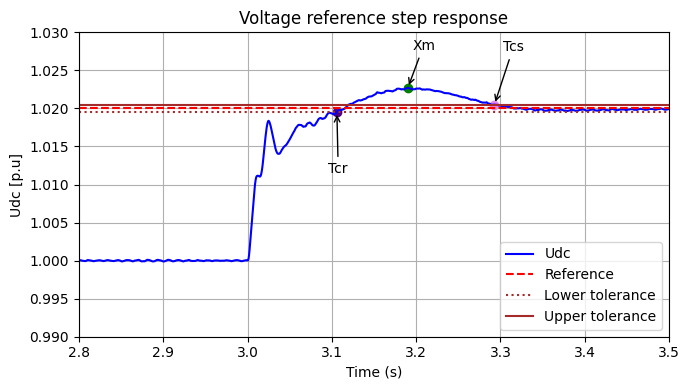

In [71]:
plot_signal_analysis(files[20], settling_window=200)

### Run Test

In [75]:
csv_files = glob.glob("..\\output\\simulation_results\\step_up_u_ref_response_results\\*.csv")
delta_u = 12.8
result_summary = []
for file in csv_files:
    test_var = 1
    try:
        results = analyze_signal(file)
    except IndexError:
        print(file)
        continue
    result_df = results["df"]
    if results["Xm"] > 0.2*delta_u:
        test_var = 0
    elif results["Tcr"] > 0.2:
        test_var = 0
    elif results["Tcs"] > 0.3:
        test_var = 0
    # elif not results["response_ok"]:
    #     test_var = 0
    result_df["Xm"] = results["Xm"]
    result_df["Tcr"] = results["Tcr"]
    result_df["Tcs"] = results["Tcs"]
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[0,:]]))
result_summary_df = pd.concat(result_summary, axis=0).reset_index(drop=True)
file_path = Path("..\\output\\simulation_results\\step_u_ref_response\\step_up_u_ref_results_summary.csv")
file_path.parent.mkdir(parents=True, exist_ok=True)
result_summary_df.to_csv(file_path, index=True)

In [74]:
result_summary_df.head()

,TIME,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,C_uF,Xm,Tcr,Tcs,score
0,4.9996,1.350541,879.385917,652.8,652.819715,10.0,400.0,1000.0,1.25,0.055,0.247,1.0
1,4.9996,1.361668,886.351527,652.8,652.830552,6.0,400.0,1000.0,1.71,0.058,0.256,1.0
2,4.9996,1.358876,884.603285,652.8,652.814396,7.0,400.0,1000.0,1.57,0.057,0.254,1.0
3,4.9996,1.356059,882.835278,652.8,652.817085,8.0,400.0,1000.0,1.46,0.056,0.251,1.0
4,4.9996,1.353448,881.097282,652.8,652.808100,9.0,400.0,1000.0,1.34,0.055,0.249,1.0


In [76]:
result_summary_df[result_summary_df['score']==1].shape

(887, 12)

In [77]:
result_summary_df.shape

(1100, 12)

## Step down 

In [104]:

def analyze_step_down_signal(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=0.98*640,
    tol_factor=0.025,
    band_percent=0.02*640,
    settling_window=200
):
    """
    Analyze a step-down signal from a CSV file.
    Settling time is calculated using a smoothed version of the signal.
    """
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[25000:, :]
    df["R_ohms"] = float(file_path.split("\\")[-1].split("_")[-2][1:])
    df["H_mH"] = float(file_path.split("\\")[-1].split("_")[-4][1:])
    df["C_uF"] = float(file_path.split("\\")[-1].split("_")[-3][1:])
    
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    within_band = (y >= lower) & (y <= upper)

    # -----------------------------
    # MIN VALUE
    # -----------------------------
    min_idx = np.argmin(y)
    min_value = y[min_idx]
    min_time = t[min_idx]

    # -----------------------------
    # TIME TO FALL INTO TOLERANCE BAND
    # -----------------------------
    fall_idx = None
    for i in range(len(y)):
        if within_band[i]:
            fall_idx = i
            break
    fall_time = t[fall_idx] if fall_idx is not None else None

      # -----------------------------
    # VALIDATION CHECK
    # Rise above upper band before min
    # -----------------------------
    response_ok = True
    if fall_idx is not None:
        iter_count = 0
        for i in range(fall_idx, min_idx):
            if y[i] > upper:
                iter_count += 1
                if iter_count > 100:
                    response_ok = False
                    break

    # -----------------------------
    # SETTLING TIME USING SMOOTH SIGNAL
    # -----------------------------
    y_smooth = smooth_signal(y, window_size=settling_window)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break
    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # RETURN RESULTS
    # -----------------------------
    results = {
        "Tcr": round(fall_time - 3., 3) if fall_time is not None else None,   # time to fall into band
        "Xm": round(target - min_value, 2),                                     # min deviation
        "Tcs": round(settling_time - 3., 3) if settling_time is not None else None,
        "response_ok": response_ok,
        "df": df.tail()
    }

    return results


def smooth_signal(y, window_size=50):
    """
    Apply moving average (running average) to smooth signal.
    """
    return pd.Series(y).rolling(window=window_size, center=True, min_periods=1).mean().values


def plot_step_down_signal(
    file_path,
    time_col="TIME",
    signal_col="Vdc",
    target=0.98*640,
    tol_factor=0.025,
    band_percent=0.02*640,
    settling_window=100
):
    # -----------------------------
    # LOAD DATA
    # -----------------------------
    df = pd.read_csv(file_path)
    df = df.iloc[25000:, :]
    t = df[time_col].values
    y = df[signal_col].values

    # -----------------------------
    # TOLERANCE BAND
    # -----------------------------
    tol = tol_factor * band_percent
    lower = target - tol
    upper = target + tol

    # -----------------------------
    # SMOOTH SIGNAL FOR SETTLING
    # -----------------------------
    y_smooth = smooth_signal(y, window_size=settling_window)
    within_band = (y >= lower) & (y <= upper)
    within_band_smooth = (y_smooth >= lower) & (y_smooth <= upper)

    # -----------------------------
    # TIME TO FALL INTO BAND
    # -----------------------------
    fall_idx = None
    for i in range(len(y)):
        if within_band[i]:
            fall_idx = i
            break
    fall_time = t[fall_idx] if fall_idx is not None else None

    # -----------------------------
    # MIN VALUE
    # -----------------------------
    min_idx = np.argmin(y)
    min_value = y[min_idx]
    min_time = t[min_idx]

    # -----------------------------
    # SETTLING TIME
    # -----------------------------
    settling_idx = None
    for i in range(len(y_smooth)):
        if within_band_smooth[i] and np.all(within_band_smooth[i:]):
            settling_idx = i
            break
    settling_time = t[settling_idx] if settling_idx is not None else None

    # -----------------------------
    # PLOTTING
    # -----------------------------
    plt.figure(figsize=(7, 4))
    ax = plt.gca()
    plt.plot(t, y/640, color="blue", label="Udc")
    # plt.plot(t, y_smooth/640, linestyle="--", label="Udc average")
    plt.axhline(target/640, linestyle="--", color="red",linewidth=1.5, label="Reference")
    plt.axhline(lower/640, linestyle=":", color="brown",linewidth=1.5, label="Lower tolerance")
    plt.axhline(upper/640, linestyle="-", color="brown",linewidth=1.5, label="Upper tolerance")

    if fall_time is not None:
        plt.scatter(fall_time, y[fall_idx]/640)
        plt.annotate(
            "Tcr",
            (fall_time, y[fall_idx]/640),
            xytext=(fall_time - 0.09, y[fall_idx]/640 + 0.008),
            arrowprops=dict(arrowstyle="->")
        )

    plt.scatter(min_time, min_value/640)
    plt.annotate(
            "Xm",
            (min_time, min_value/640),
            xytext=(min_time + 0.005, min_value/640 + 0.006),
            arrowprops=dict(arrowstyle="->")
        )

    if settling_time is not None:
        plt.scatter(settling_time, y[settling_idx]/640)
        plt.annotate(
            "Tcs",
            (settling_time, y[settling_idx]/640),
            xytext=(settling_time + 0.01, y[settling_idx]/640 + 0.007),
            arrowprops=dict(arrowstyle="->")
        )

    plt.xlabel("Time (s)")
    plt.ylabel("Udc [p.u]")
    plt.title("Voltage reference step response")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.legend(loc=1)
    plt.ylim([0.97, 1.005])
    plt.xlim([2.8, 3.5])
    plt.grid()
    
    file_path = Path("../output/simulation_results/step_u_ref_response/step_down.png")
    file_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(file_path)
    
    plt.show()

In [79]:
files = glob.glob("..\\output\\simulation_results\\step_down_u_ref_response_results\\*.csv")

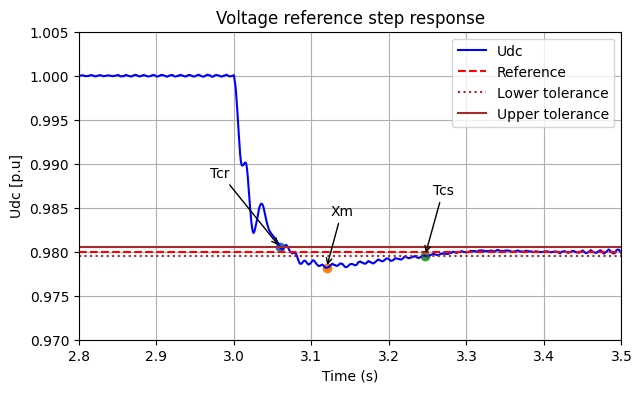

In [105]:
plot_step_down_signal(files[20], settling_window=200)

### Run Test

In [84]:
csv_files = glob.glob("..\\output\\simulation_results\\step_down_u_ref_response_results\\*.csv")
delta_u = 12.8
result_summary = []
for file in csv_files:
    test_var = 1
    try:
        results = analyze_step_down_signal(file)
    except IndexError:
        print(file)
        continue
    result_df = results["df"]
    if results["Xm"] > 0.2*delta_u:
        test_var = 0
    elif results["Tcr"] > 0.2:
        test_var = 0
    elif results["Tcs"] > 0.3:
        test_var = 0
    # elif not results["response_ok"]:
    #     test_var = 0
    result_df["Xm"] = results["Xm"]
    result_df["Tcr"] = results["Tcr"]
    result_df["Tcs"] = results["Tcs"]
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[0,:]]))
result_summary_df = pd.concat(result_summary, axis=0).reset_index(drop=True)
file_path = Path("..\\output\\simulation_results\\step_u_ref_response\\step_down_u_ref_results_summary.csv")
file_path.parent.mkdir(parents=True, exist_ok=True)
result_summary_df.to_csv(file_path, index=True)

In [85]:
result_summary_df.head()

,TIME,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,C_uF,Xm,Tcr,Tcs,score
0,4.9996,1.403832,877.440321,627.2,627.404037,10.0,400.0,1000.0,1.21,0.053,0.246,1.0
1,4.9996,1.415581,885.356305,627.2,627.398610,6.0,400.0,1000.0,1.59,0.056,0.254,1.0
2,4.9996,1.413557,883.226608,627.2,627.197932,7.0,400.0,1000.0,1.50,0.054,0.252,1.0
3,4.9996,1.409911,881.632012,627.2,627.078898,8.0,400.0,1000.0,1.39,0.054,0.249,1.0
4,4.9996,1.407677,879.402232,627.2,627.170469,9.0,400.0,1000.0,1.29,0.053,0.247,1.0


In [86]:
result_summary_df.shape

(1100, 12)

In [87]:
result_summary_df[result_summary_df['score']==1].shape

(909, 12)

## Combined result summary

In [ ]:
summary_files = glob.glob("..\\output\\simulation_results\\step_u_ref_response\\step*.csv")
summary_files

In [ ]:
df1 = pd.read_csv(summary_files[0], index_col=0)
df1 = df1.drop(columns=['TIME'])
df1 = df1[df1['score'] == 1]
df1.head()

In [ ]:
df2 = pd.read_csv(summary_files[1], index_col=0)
df2 = df2.drop(columns=['TIME'])
df2 = df2[df2['score'] == 1]
df2.head()

In [ ]:
merged_df = pd.merge(
    df1,
    df2,
    on=['R_ohms', 'H_mH', 'C_uF'],   # columns to match on
    how='inner',           # change to 'left', 'right', or 'outer' if needed
    suffixes=('_u_down', '_u_up')
)

In [ ]:
merged_df.drop(columns=['Vdc_ref_u_up', 'score_u_down'], inplace=True)
merged_df.rename(columns={'score_u_up': 'score'}, inplace=True)
merged_df.to_csv('..\\output\\simulation_results\\step_u_ref_response\\successful_tests.csv', index=False)

## Test envelope

In [3]:
df = pd.read_csv("..\\output\\simulation_results\\step_u_ref_response\\successful_tests.csv")
x = df['R_ohms']
y = df['H_mH']
z = df['C_uF']
df.head()

,Idc_u_down,Pac_u_down,Vdc_ref_u_down,Vdc_u_down,R_ohms,H_mH,C_uF,Xm_u_down,Tcr_u_down,Tcs_u_down,Idc_u_up,Pac_u_up,Vdc_u_up,Xm_u_up,Tcr_u_up,Tcs_u_up,score
0,1.403832,877.440321,627.2,627.404037,10.0,400.0,1000.0,1.21,0.053,0.246,1.350541,879.385917,652.819715,1.25,0.055,0.247,1.0
1,1.415581,885.356305,627.2,627.398610,6.0,400.0,1000.0,1.59,0.056,0.254,1.361668,886.351527,652.830552,1.71,0.058,0.256,1.0
2,1.413557,883.226608,627.2,627.197932,7.0,400.0,1000.0,1.50,0.054,0.252,1.358876,884.603285,652.814396,1.57,0.057,0.254,1.0
3,1.409911,881.632012,627.2,627.078898,8.0,400.0,1000.0,1.39,0.054,0.249,1.356059,882.835278,652.817085,1.46,0.056,0.251,1.0
4,1.407677,879.402232,627.2,627.170469,9.0,400.0,1000.0,1.29,0.053,0.247,1.353448,881.097282,652.808100,1.34,0.055,0.249,1.0


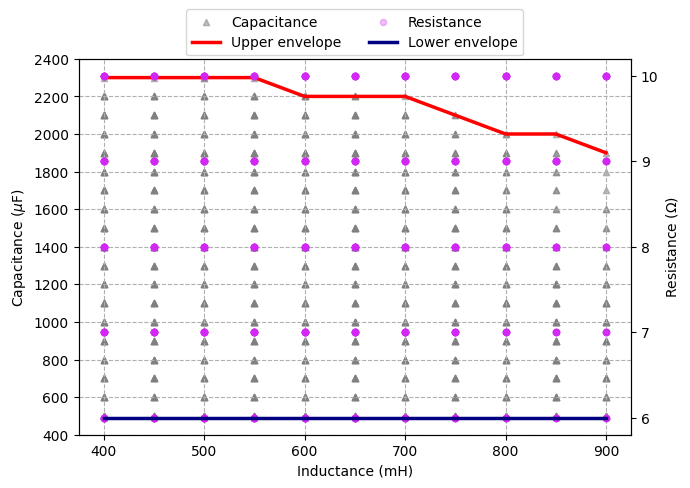

In [4]:
# Group by H and get global min/max
grouped = df.groupby("H_mH")

C_max = grouped["C_uF"].max()
C_min = grouped["C_uF"].min()

R_max = grouped["R_ohms"].max()
R_min = grouped["R_ohms"].min()

x = C_max.index  # H values


# -----------------------------
# FIGURE SETUP (size added)
# -----------------------------
fig, ax1 = plt.subplots(figsize=(7, 5))

# -----------------------------
# LEFT AXIS (Capacitance)
# -----------------------------
ax1.scatter(
    df["H_mH"],
    df["C_uF"],
    color='grey',
    alpha=0.5,
    s=20,
    marker='^',
    label="Capacitance"
)

ax1.plot(
    x,
    C_max,
    color='red',
    linewidth=2.5,
    label="Upper envelope"
)

ax1.set_xlabel("Inductance (mH)")
ax1.set_ylabel(r"Capacitance ($\mu$F)")
ax1.grid(True, linestyle="--")
ax1.set_ylim(400, 2400)
ax1.yaxis.set_major_locator(MultipleLocator(200))


# -----------------------------
# RIGHT AXIS (Resistance)
# -----------------------------
ax2 = ax1.twinx()

ax2.scatter(
    df["H_mH"],
    df["R_ohms"],
    color='#D327F5',
    alpha=0.3,
    s=20,
    label="Resistance"
)

ax2.plot(
    x,
    R_min,
    linestyle='-',
    color='navy',
    linewidth=2.5,
    label="Lower envelope"
)

ax2.set_ylabel(r"Resistance ($\Omega$)")
ax2.yaxis.set_major_locator(MultipleLocator(1))


# -----------------------------
# COMBINED LEGEND (OUTSIDE TOP-RIGHT)
# -----------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()


ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),  # top center, slightly above plot
    ncol=2,
    frameon=True
)

# Leave space for legend
plt.tight_layout()

file_path = Path("../output/simulation_results/step_u_ref_response/u_ref_response_envelope.jpg")
file_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(file_path)

plt.show()